In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import random

from time import time

from scipy.special import comb, loggamma, lambertw
from scipy.stats import multinomial, expon

import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test

from silence_tensorflow import silence_tensorflow
silence_tensorflow()
import tensorflow as tf
import tensorflow_probability as tfp
from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

import os, shutil, sys
from pathlib import Path
import json
import subprocess

import thetaflow as thf
# import modelnn2 as thf
print("Thetaflow version: {}".format(thf.__version__))

sys.path.append("../")
# import mpscr_models as mpscr
import mpscr_models_flexible as mpscr
import pwexp_flexible as pwexp
import gndr_utils as utils
import mps

I0000 00:00:1786493446.496453   45851 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786493447.499197   45851 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Thetaflow version: 0.0.35


# Load data

In [2]:
df = pd.read_csv("OASIS Data/patients_full_data.csv")
print("Data dimensions: {}".format(df.shape))
df.head(3)

Data dimensions: (737, 278)


,Unnamed: 0,oasis_id,time_days,delta,age_at_entry,age_at_death,gender,apoe,days_to_visit,age_at_visit,...,vol_wm_rh_superiorfrontal,vol_wm_rh_superiorparietal,vol_wm_rh_superiortemporal,vol_wm_rh_supramarginal,vol_wm_rh_frontalpole,vol_wm_rh_temporalpole,vol_wm_rh_transversetemporal,vol_wm_rh_insula,vol_left_unsegmented_white_matter,vol_right_unsegmented_white_matter
0,0,OAS30001,5055,0,65.1945,NaN,2,23.0,5184,79.40,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,OAS30002,2590,0,67.2521,76.9397,1,34.0,2961,75.36,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,OAS30003,5093,0,58.8137,NaN,2,33.0,5651,74.30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


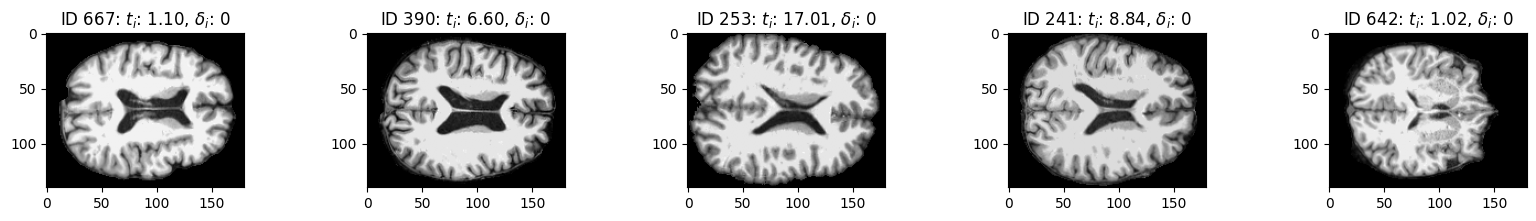

In [3]:
x = np.load("OASIS Data/patients_images.npy")
x = np.expand_dims(x, axis=-1)

np.random.seed(12)

random_idx = np.random.choice(np.arange(x.shape[0]), size = 5)

fig, ax = plt.subplots(nrows = 1, ncols = 5, figsize = (20,2))

for i, a in enumerate(ax):
    idx = random_idx[i]
    a.imshow(x[idx,:,:,0], cmap = "gray")
    a.set_title(r"ID {}: $t_i$: {:.2f}, $\delta_i$: {}".format(idx, df.loc[idx, "time_days"] / 365, df.loc[idx, "delta"]))

Applying administrative Type I censorship in 34 patients, of which 2 had observed events.
Train dimension: (552,)
Test dimension: (185,)


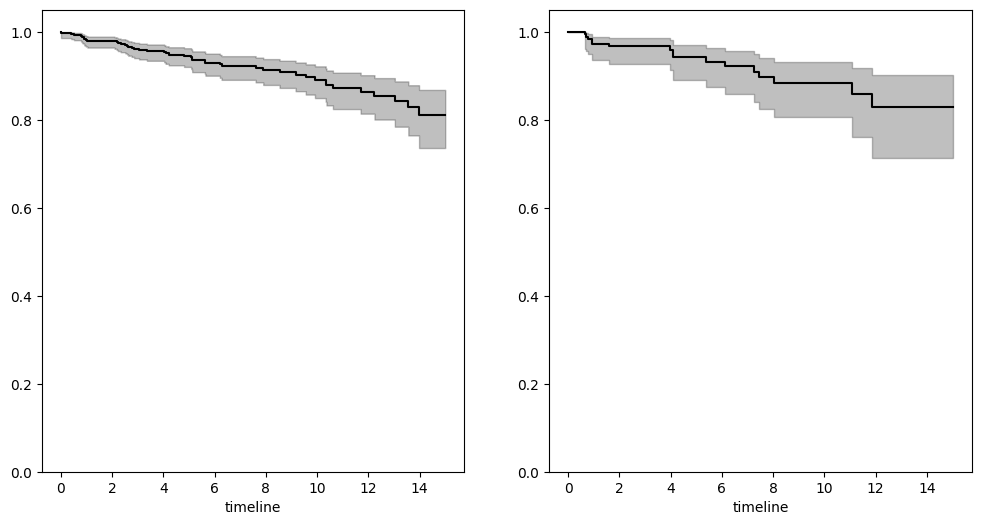

In [4]:
import oasis_utils

# Load OASIS data
# - Split into 75%/25% train/test sets
# - Stratify data according to the number of observed events
y_train, delta_train, x_train, y_test, delta_test, x_test =\
oasis_utils.load_oasis_data(long_term_limit = 15, train_size = 0.75, random_state = 20, stratify = True, verbose = True)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

km = lifelines.KaplanMeierFitter()
km.fit(y_train, delta_train)
km.plot(ax = ax[0], ci_show = True, show_censors = False, label = "Kaplan-Meier", color = "black", legend = False)

km = lifelines.KaplanMeierFitter()
km.fit(y_test, delta_test)
km.plot(ax = ax[1], ci_show = True, show_censors = False, label = "Kaplan-Meier", color = "black", legend = False)

ax[0].set_ylim(0, 1.05)
ax[1].set_ylim(0, 1.05)
plt.show()

### Plot functions

The function below plot the Kaplan-Meier estimates alongside the patients individual survival curves for both censored and susceptible patients. The censored Kaplan-Meier will always be constant at 1. The function returns both plots for the train and test data sets.

In [5]:
def plot_censored_susceptible(model_results, ax1 = None, ax2 = None, ax3 = None, ax4 = None, show_individual = True, plot_km = True, color = "red"):
    ts_grid = model_results["ts_grid"]

    delta_train = model_results["delta_train"]
    delta_test = model_results["delta_test"]
    
    p_train = np.reshape( model_results["p_train"], [-1,1] )
    p_test = np.reshape( model_results["p_test"], [-1,1] )
    
    S_ts_train = model_results["S_ts_train"]
    S_ts_test = model_results["S_ts_test"]

    if(p_train.shape[0] > 1):
        S_ts_train_censored = S_ts_train[delta_train == 0, :]
        S_ts_train_uncensored = (S_ts_train[delta_train == 1, :] - p_train[delta_train == 1]) / (1-p_train[delta_train == 1])

        S_ts_test_censored = S_ts_test[delta_test == 0, :]
        S_ts_test_uncensored = (S_ts_test[delta_test == 1, :] - p_test[delta_test == 1]) / (1-p_test[delta_test == 1])
    else:
        S_ts_train_censored = S_ts_train
        S_ts_train_uncensored = (S_ts_train - p_train) / (1-p_train)

        S_ts_test_censored = S_ts_test
        S_ts_test_uncensored = (S_ts_test - p_test) / (1-p_test)

    fresh_plot = False
    if(ax1 is None or ax2 is None or ax3 is None or ax4 is None):
        fresh_plot = True
        fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (12,6))
        ax1 = ax[0,0]
        ax2 = ax[0,1]
        ax3 = ax[1,0]
        ax4 = ax[1,1]
    
    utils.average_kaplan_meier(ts_grid,
                               S_ts_train_censored,
                               y_train[delta_train == 0], delta_train[delta_train == 0], show_individual = show_individual, ax = ax1, color = color)
    ax1.set_title("Train set censored")
    
    utils.average_kaplan_meier(ts_grid,
                               S_ts_train_uncensored,
                               y_train[delta_train == 1], delta_train[delta_train == 1], show_individual = show_individual, ax = ax2, color = color)
    ax2.set_title("Train set uncensored")


    utils.average_kaplan_meier(ts_grid,
                               S_ts_test_censored,
                               y_test[delta_test == 0], delta_test[delta_test == 0], show_individual = show_individual, ax = ax3, color = color)
    ax3.set_title("Test set censored")
    
    utils.average_kaplan_meier(ts_grid,
                               S_ts_test_uncensored,
                               y_test[delta_test == 1], delta_test[delta_test == 1], show_individual = show_individual, ax = ax4, color = color)
    ax4.set_title("Test set uncensored")

    if(fresh_plot):
        fig.tight_layout()

### Simple model

Here, we consider the MPScr with no covariates. That is, we assume the cure probability and both parameters from the chosen distribution (from the MPS family) to be global constants. The main interest in fitting this model is in assessing whether the brain MR images are, in fact, bringing new information to the study of the lifetimes by showing better evaluation metrics.

In [6]:
mps_spec = mpscr.MPSPoisson()
weibull_spec = mpscr.BaseWeibull()
base_spec = weibull_spec

data_train = [y_train, delta_train]

with tf.device("/CPU:0"):
    poisson_simple_model = mpscr.build_simple_mpscr_model(y_train, delta_train, mps_spec, base_spec, seed = 10 )
    poisson_simple_model.train_model(epochs = 5000, x = None, data = data_train,
                                     shuffle = True,
                                     get_covariances = True,
                                     validation = True, val_prop = 0.2, force_training_validation = True,
                                     optimizer_independent = optimizers.Adam(learning_rate = 0.01),
                                     optimizer_nn = optimizers.Adam(learning_rate = 1.0e-4),
                                     fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                                     early_stopping = True, early_stopping_patience = 50,
                                     early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-3,
                                     reduce_lr = True, reduce_lr_warmup = 0,
                                     reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 25,
                                     reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                     fine_tune = True,
                                     finetune_early_stopping = True, finetune_early_stopping_patience = 50,
                                     finetune_early_stopping_warmup = 10, finetune_early_stopping_min_delta = 1.0e-2,
                                     finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                                     finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-2, finetune_reduce_lr_patience = 25,
                                     finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                                     deterministic = True,
                                     verbose = True, print_freq = 1)
    poisson_simple_results = poisson_simple_model.get_survival_cure(y_train, delta_train, y_test, delta_test, ngrid = 100)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 3457 / 5000 ]  | Avg. Train NLL:  0.456766456 | Best Avg. Train NLL:  0.456766456 | Avg. Validation NLL:  0.507814 | Speed:  0.00110126787  epoch/s    | Elapsed Time:  3.80708313  s      
Convergence criterion reached. Stopping.
Restoring best weights...
Optimizing... Epoch: [ 3458 / 5000 ]  | Avg. Train NLL:  0.456765413 | Best Avg. Train NLL:  0.456765413 | Avg. Validation NLL:  0.50781244 | Speed:  0.0011012652  epoch/s    | Elapsed Time:  3.80817485  s   
Done.
Extracting covariance structure.
Done.
Optimization finished in 7.901 seconds.


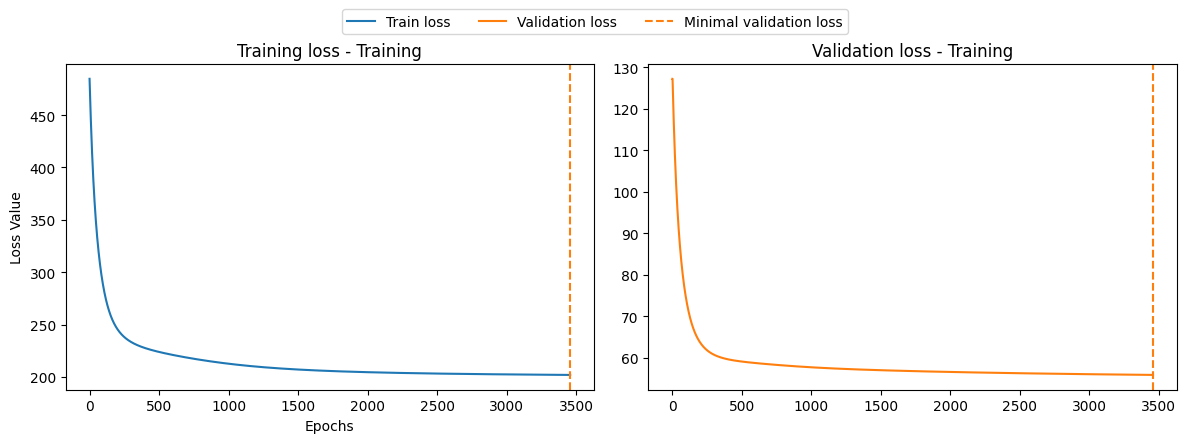

In [7]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))
utils.plot_model_convergence( poisson_simple_model, ax1 = ax[0], ax2 = ax[1] )

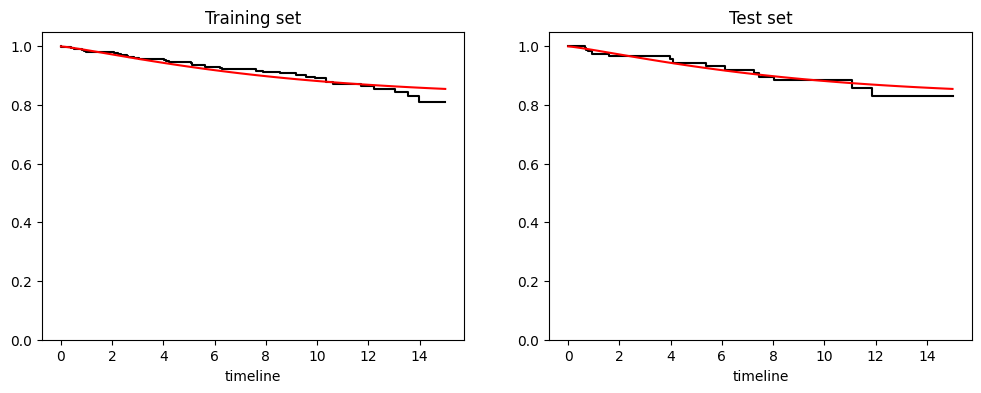

In [8]:
ts_grid = poisson_simple_results["ts_grid"]
p_train = poisson_simple_results["p_train"]
p_test = poisson_simple_results["p_test"]
S_ts_train = poisson_simple_results["S_ts_train"]
S_ts_test = poisson_simple_results["S_ts_test"]

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))

utils.average_kaplan_meier_train_test(ts_grid,
                                      S_ts_train, S_ts_test,
                                      y_train, delta_train, y_test, delta_test, show_individual = False, ax1 = ax[0], ax2 = ax[1])

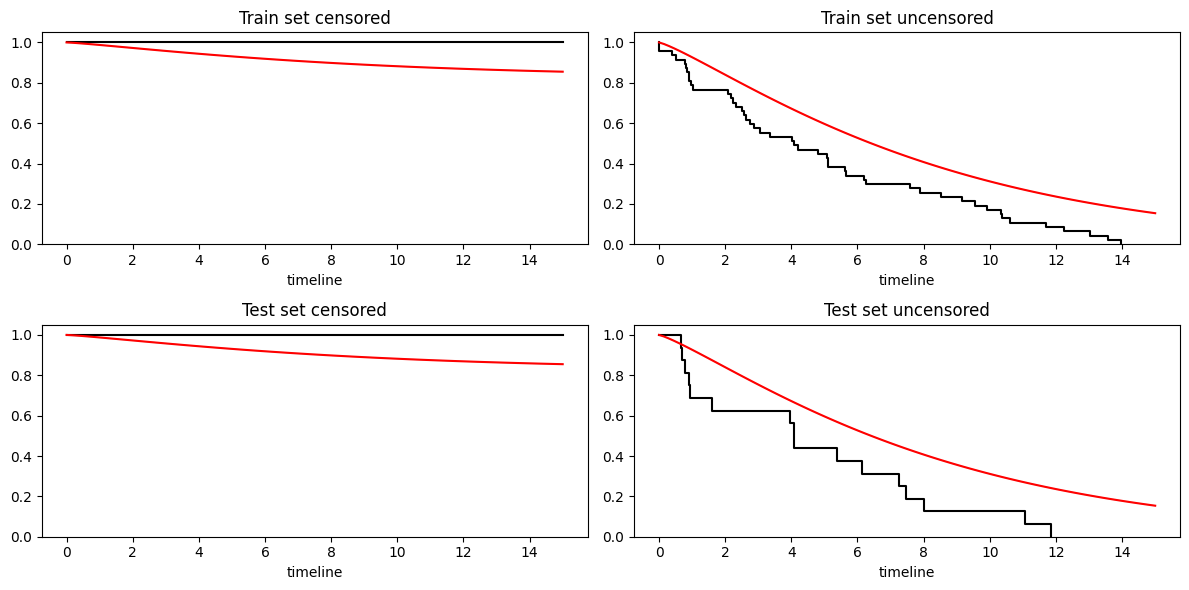

In [9]:
plot_censored_susceptible( poisson_simple_results )

## Grad-CAM structure

For the next implementations, it will be interest to use the Grad-CAM method to assess, at some extent, how the brain images are "seen" by the models themselves. We expect that the model will mostly "look at" the brain structure to find the desirable patterns intrinsic to Alzheimer's Disease (AD).

That approach is far from showing the exact patterns being considered by the CNN's. However, it allows us to determine whether the model is not simply learning to classify risks based on the background shape or possibly on completely arbitrary regions of the image.

In [10]:
import cv2

def get_last_conv_layer_index(model):
    conv_indices = []
    for i, layer in enumerate(model.layers):
        if(hasattr(layer, "convolution_op")):
            conv_indices.append(i)
    return conv_indices[-1]

def generate_gradcam(model, img):
    i_last_conv = get_last_conv_layer_index(model)
    img_tensor = tf.convert_to_tensor(img, dtype=tf.float32)
    x = model.layers[0](img_tensor)
    with tf.GradientTape() as tape:
        for i in range(1, len(model.layers)):
            # If we are at the last convolution layer, get its output and save it in a separate variable
            if(i == i_last_conv):
                last_conv_out = x = model.layers[i](x)
                tape.watch(last_conv_out)
            # The next layer output is based on the last convolutional layer output
            elif(i == (i_last_conv + 1)):
                x = model.layers[i](last_conv_out)
            # All the other layers are simply applications of each layer
            else:
                x = model.layers[i](x)
        # Get the last output of the last layer, associated to the cure probability
        target_score = x[0,-1]

    grads = tape.gradient(target_score, last_conv_out)

    # Global Average Pooling of the gradients to get the weight of each feature map
    pooled_grads = tf.reduce_mean(grads, axis = (0, 1, 2))

    # Multiply the feature maps by their gradient weights
    last_conv_out = last_conv_out[0] # Drop the batch dimension
    heatmap = last_conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Apply ReLU (we only care about pixels that had a *positive* influence on the prediction)
    heatmap = tf.nn.relu(heatmap)

    # Normalize the heatmap to be between 0 and 1
    heatmap_max = tf.math.reduce_max(heatmap)
    if heatmap_max != 0:
        heatmap = heatmap / heatmap_max

    return heatmap.numpy()

def gradcam_img(model, img):
    heatmap = generate_gradcam(model, img)
    original_image = img[0, :, :, 0]
    heatmap_resized = cv2.resize(heatmap, (original_image.shape[1], original_image.shape[0]))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    return heatmap_resized

def plot_gradcam(model, img):
    """
        Overlays the Grad-CAM heatmap onto the original MRI slice.
    """
    # Get the Grad-CAM heatmap
    heatmap = generate_gradcam(model, img)
    
    # Extract the original 2D image (dropping batch and channel dims)
    original_image = img[0, :, :, 0]
    
    # Resize heatmap to match the original image size -> OpenCV format (width, height)
    heatmap_resized = cv2.resize(heatmap, (original_image.shape[1], original_image.shape[0]))
    
    # Convert heatmap to RGB format for visualization
    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    # Convert original image to RGB
    original_img_norm = np.uint8(255 * (original_image / np.max(original_image)))
    original_colored = cv2.cvtColor(original_img_norm, cv2.COLOR_GRAY2RGB)
    
    # Blend them together (0.6 opacity for MRI, 0.4 for heatmap)
    superimposed_img = cv2.addWeighted(original_colored, 0.6, heatmap_colored, 0.4, 0)
    
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    ax[0].imshow(original_image, cmap='gray')
    ax[0].set_title("Original MRI Slice")
    ax[0].axis('off')
    
    ax[1].imshow(heatmap_resized, cmap='jet')
    ax[1].set_title("Raw Grad-CAM")
    ax[1].axis('off')
    
    ax[2].imshow(superimposed_img)
    ax[2].set_title("Overlay")
    ax[2].axis('off')
    
    plt.show()

## Neural network architecture

### Convolutional neural network - global base parameters

First, we will consider the standard promotion time cure model proposed by Xie & Yu (2021). For that, we consider the Poisson distribution for the number of latent causes.

For now we will consider the Poisson distribution. We will only expand the alternative MPS distributions later on this notebook.

In [12]:
mps_spec = mpscr.MPSPoisson()
weibull_spec = mpscr.BaseWeibull()
base_spec = weibull_spec

flexible_neural_network, flexible_neural_network_call, flexible_neural_network_call_nolast = \
oasis_utils.build_neural_network_structure(1)

poisson_medium_model = mpscr.build_medium_mpscr_model(y_train, delta_train, x_train.shape[1:], mps_spec, base_spec,
                                                      neural_network = flexible_neural_network, neural_network_call = flexible_neural_network_call,
                                                      neural_network_call_nolast = flexible_neural_network_call_nolast,
                                                      seed = 10)

keras.Model.summary(poisson_medium_model)

Model: "model_nn_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 140, 180, 4)    │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 70, 90, 8)      │           808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 35, 45, 16)     │         3,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 17, 22, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 11, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 191,850 (749.41 KB)

 Trainable params: 191,850 (749.41 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
data_train = [y_train, delta_train]
data_test = [y_test, delta_test]

mps_spec = mpscr.MPSPoisson()
weibull_spec = mpscr.BaseWeibull()
base_spec = weibull_spec

medium_neural_network, medium_neural_network_call, medium_neural_network_call_nolast = \
oasis_utils.build_neural_network_structure(1)

with tf.device("/GPU:0"):
    poisson_medium_model = mpscr.build_medium_mpscr_model(y_train, delta_train, x_train.shape[1:], mps_spec, base_spec,
                                                            neural_network = medium_neural_network, neural_network_call = medium_neural_network_call,
                                                            neural_network_call_nolast = medium_neural_network_call_nolast,
                                                            seed = 10)
    poisson_medium_model.train_model(
        epochs = 5000, x = x_train, data = data_train,
        shuffle = True,
        get_covariances = True,
        validation = True, val_prop = 0.2, force_training_validation = False,
        optimizer_independent = optimizers.Adam(learning_rate = 0.01),
        optimizer_nn = optimizers.Adam(learning_rate = 1.0e-4),
        fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
        early_stopping = True, early_stopping_patience = 50,
        early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-3,
        reduce_lr = True, reduce_lr_warmup = 0,
        reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 25,
        reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
        fine_tune = True,
        finetune_early_stopping = True, finetune_early_stopping_patience = 50,
        finetune_early_stopping_warmup = 10, finetune_early_stopping_min_delta = 1.0e-2,
        finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
        finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-2, finetune_reduce_lr_patience = 25,
        finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
        deterministic = True,
        verbose = True, print_freq = 1
    )
    
    poisson_medium_results = poisson_medium_model.get_survival_cure(y_train, delta_train, x_train, y_test, delta_test, x_test, ngrid = 100)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 382 / 5000 ]  | Avg. Train NLL:  0.480427623 | Avg. Validation NLL:  0.540882051 | Best Avg. Validation NLL:  0.54012382 | Speed:  0.0746313408  epoch/s    | Elapsed Time:  28.5091705  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 1062 / 5000 ]  | Avg. Train NLL:  0.438202351 | Best Avg. Train NLL:  0.438202351 | Avg. Validation NLL:  0.519648254 | Speed:  0.0348869897  epoch/s    | Elapsed Time:  37.049984  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 68.806 seconds.


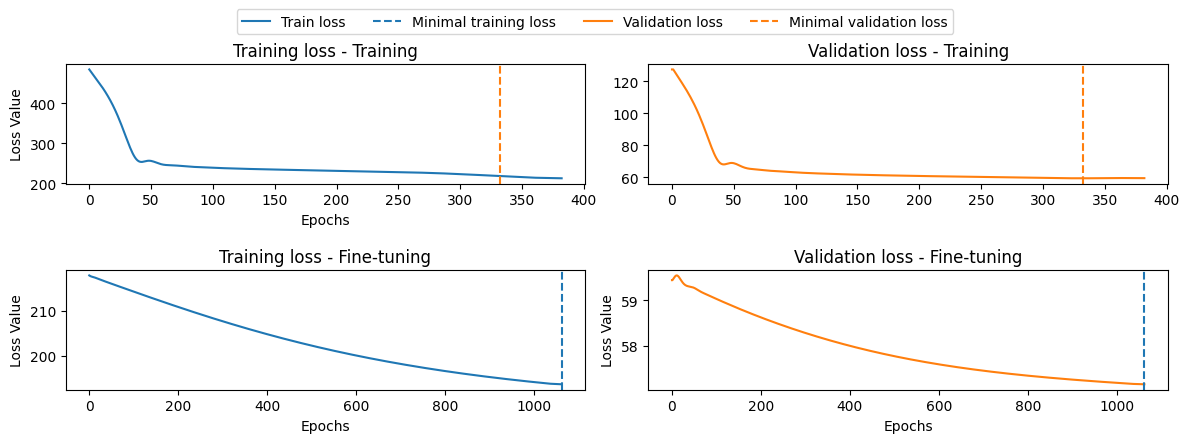

In [14]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (12,4))
utils.plot_model_convergence( poisson_medium_model, ax1 = ax[0,0], ax2 = ax[0,1], ax3 = ax[1,0], ax4 = ax[1,1] )

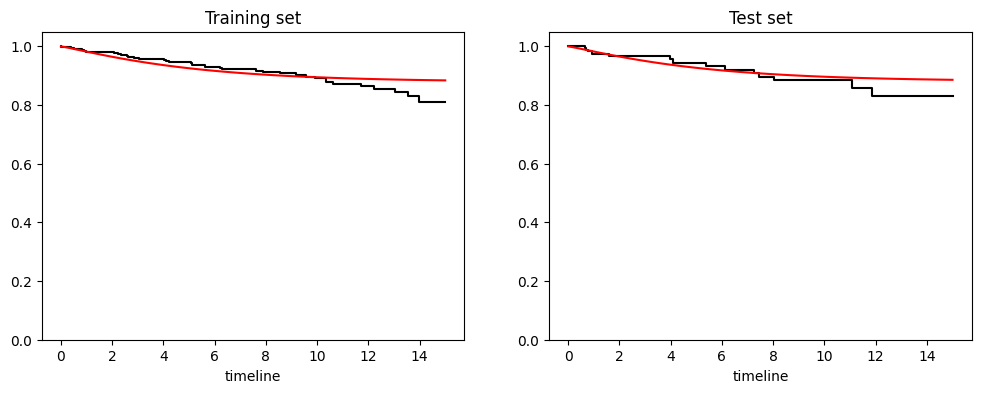

In [15]:
ts_grid = poisson_medium_results["ts_grid"]
p_train = poisson_medium_results["p_train"]
p_test = poisson_medium_results["p_test"]
S_ts_train = poisson_medium_results["S_ts_train"]
S_ts_test = poisson_medium_results["S_ts_test"]

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))

utils.average_kaplan_meier_train_test(ts_grid,
                                      S_ts_train, S_ts_test,
                                      y_train, delta_train, y_test, delta_test, show_individual = False, ax1 = ax[0], ax2 = ax[1])

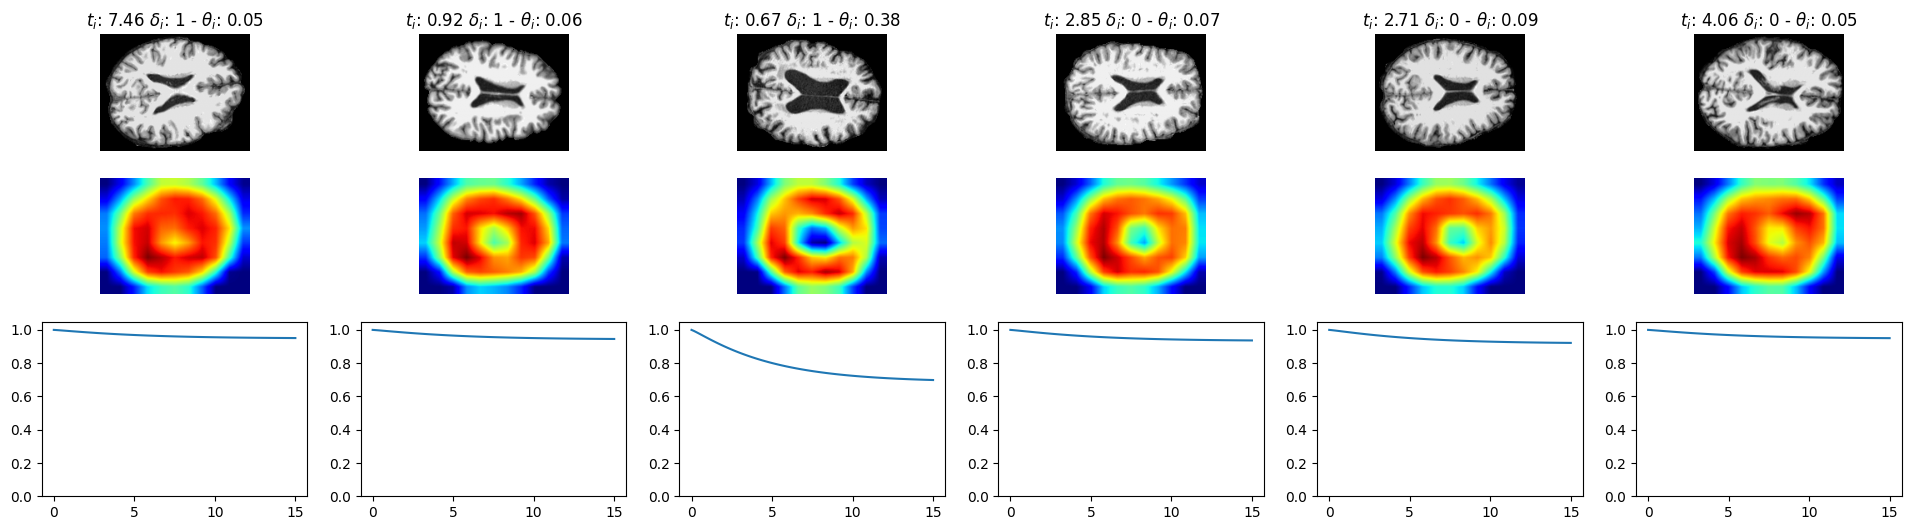

In [16]:
# np.random.seed(3)
np.random.seed(15)

# Select five patients from the test set who happened to be diagnosed with AD
susceptible_idx = np.random.choice(np.arange(x_test.shape[0]), size = 6, p = delta_test / np.sum(delta_test))
# Sample 5 patients from the test set whose lifetimes are censored
idx = np.random.choice(np.arange(x_test.shape[0]), size = 6, p = (1-delta_test) / np.sum(1-delta_test))

idx[:3] = susceptible_idx[:3]

fig, ax = plt.subplots(nrows = 3, ncols = 6, figsize = (24,6),
                       gridspec_kw = {
                           'height_ratios': [1,1,1.5],
                           'width_ratios': [1,1,1,1,1,1]
                       })
    
t = np.linspace(0.01, np.max(y_train))

for i in range(6):
    ax[0,i].imshow( x_test[idx[i]], cmap = "gray" )
    ax[0,i].set_title(r"$t_i$: {:.2f} $\delta_i$: {} - $\theta_i$: {:.2f}".format(y_test.iloc[idx[i]], delta_test.iloc[idx[i]], poisson_medium_results["theta_test"][idx[i]]))
    ax[0,i].set_axis_off()

    gradcam = gradcam_img(poisson_medium_model, x_test[idx[i]:(idx[i]+1)] )
    ax[1,i].imshow( gradcam, cmap = "jet" )
    ax[1,i].set_axis_off()

    ax[2,i].plot( poisson_medium_results["ts_grid"].flatten(), poisson_medium_results["S_ts_test"][idx[i], :] )
    ax[2,i].set_ylim(0, 1.05)

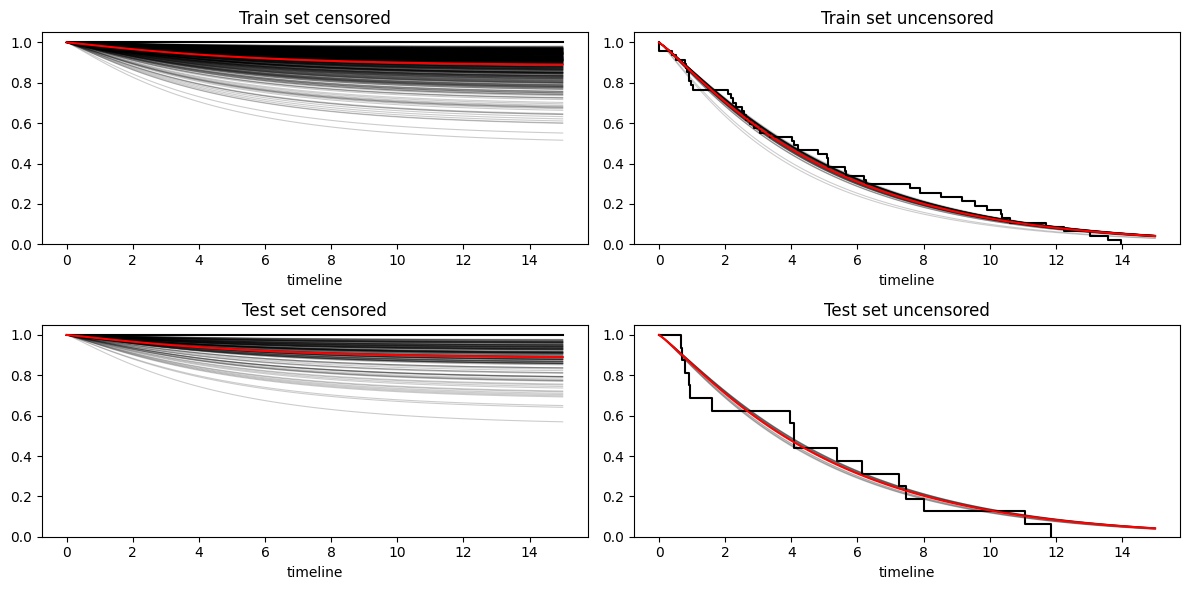

In [17]:
plot_censored_susceptible( poisson_medium_results )

## Model alternative to the Poisson

The function below merges all model types presented above into a single function call. That way, we can seamlesly call very different model structures while keeping the same overall results pattern for easy comparison between all models. We are interested both in selecting the best model structure and the correct distribution for the latent causes according to the data.

In [18]:
def fit_model(dist, model_type, y_train, delta_train, x_train, y_test, delta_test, x_test, fixed_q = 0.0, epochs = 10000):
    weibull_spec = mpscr.BaseWeibull()
    base_spec = weibull_spec

    dist = dist.lower()
    if(dist == "poisson"):
        model_spec = mpscr.MPSPoisson()
    elif(dist == "bin" or dist == "binomial"):
        model_spec = mpscr.MPSBinomial(fixed_q)
    elif(dist == "negbin"):
        model_spec = mpscr.MPSNegBinomial()
    elif(dist == "geometric"):
        model_spec = mpscr.MPSNegBinomial(1.0)
    elif(dist == "log" or dist == "logarithmic"):
        model_spec = mpscr.MPSLogarithmic()
    elif(dist == "rgp"):
        model_spec = mpscr.MPSRGP()
    elif(dist == "borel"):
        # The Borel distribution is the Restricted Generalized Poisson with shape parameter q = 1
        model_spec = mpscr.MPSRGP(1.0)
    elif(dist == "geeta"):
        model_spec = mpscr.MPSGeeta()
    elif(dist == "haight" or dist == "catalan"):
        # The Haight distribution is the Geeta with shape parameter q = 2
        model_spec = mpscr.MPSGeeta(2.0)
    else:
        raise Exception("Please, provide a valid subfamily name.")

    data_train = [y_train, delta_train]
    if(model_type == "simple"):
        with tf.device("/CPU:0"):
            model = mpscr.build_simple_mpscr_model(y_train, delta_train, model_spec, base_spec, seed = 10 )
            model.train_model(epochs = epochs, x = None, data = data_train,
                              shuffle = True,
                              get_covariances = True,
                              validation = True, val_prop = 0.2, force_training_validation = True,
                              optimizer_independent = optimizers.Adam(learning_rate = 0.01),
                              optimizer_nn = optimizers.Adam(learning_rate = 1.0e-4),
                              fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                              early_stopping = True, early_stopping_patience = 50,
                              early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-3,
                              reduce_lr = True, reduce_lr_warmup = 0,
                              reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 25,
                              reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                              fine_tune = True,
                              finetune_early_stopping = True, finetune_early_stopping_patience = 50,
                              finetune_early_stopping_warmup = 10, finetune_early_stopping_min_delta = 1.0e-2,
                              finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                              finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-2, finetune_reduce_lr_patience = 25,
                              finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                              deterministic = True,
                              verbose = True, print_freq = 1)
            model_results = model.get_survival_cure(y_train, delta_train, y_test, delta_test, ngrid = 100)
    elif(model_type == "medium"):
        medium_neural_network, medium_neural_network_call, medium_neural_network_call_nolast = oasis_utils.build_neural_network_structure(1)
        with tf.device("/GPU:0"):
            model = mpscr.build_medium_mpscr_model(y_train, delta_train, x_train.shape[1:], model_spec, base_spec,
                                                   neural_network = medium_neural_network, neural_network_call = medium_neural_network_call,
                                                   neural_network_call_nolast = medium_neural_network_call_nolast,
                                                   seed = 10)
            model.train_model(epochs = epochs, x = x_train, data = data_train,
                              shuffle = True,
                              get_covariances = True,
                              validation = True, val_prop = 0.2, force_training_validation = False,
                              optimizer_independent = optimizers.Adam(learning_rate = 0.01),
                              optimizer_nn = optimizers.Adam(learning_rate = 1.0e-4),
                              fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                              early_stopping = True, early_stopping_patience = 50,
                              early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-3,
                              reduce_lr = True, reduce_lr_warmup = 0,
                              reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 25,
                              reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                              fine_tune = True,
                              finetune_early_stopping = True, finetune_early_stopping_patience = 50,
                              finetune_early_stopping_warmup = 10, finetune_early_stopping_min_delta = 1.0e-2,
                              finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                              finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-2, finetune_reduce_lr_patience = 25,
                              finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                              deterministic = True,
                              verbose = True, print_freq = 1)
            model_results = model.get_survival_cure(y_train, delta_train, x_train, y_test, delta_test, x_test, ngrid = 100)
    elif(model_type == "flexible"):
        flexible_neural_network, flexible_neural_network_call, flexible_neural_network_call_nolast = oasis_utils.build_neural_network_structure(base_spec.n_parameters+1)
        with tf.device("/GPU:0"):
            model = mpscr.build_flexible_mpscr_model(y_train, delta_train, x_train.shape[1:], model_spec, base_spec,
                                                     neural_network = flexible_neural_network, neural_network_call = flexible_neural_network_call,
                                                     neural_network_call_nolast = flexible_neural_network_call_nolast,
                                                     seed = 10)
            model.train_model(epochs = 5000, x = x_train, data = data_train,
                              shuffle = True,
                              get_covariances = True,
                              validation = True, val_prop = 0.2, force_training_validation = False,
                              optimizer_independent = optimizers.Adam(learning_rate = 0.01),
                              optimizer_nn = optimizers.Adam(learning_rate = 1.0e-4),
                              fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                              early_stopping = True, early_stopping_patience = 50,
                              early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-3,
                              reduce_lr = True, reduce_lr_warmup = 0,
                              reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 25,
                              reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                              fine_tune = True,
                              finetune_early_stopping = True, finetune_early_stopping_patience = 50,
                              finetune_early_stopping_warmup = 10, finetune_early_stopping_min_delta = 1.0e-2,
                              finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                              finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-2, finetune_reduce_lr_patience = 25,
                              finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                              deterministic = True,
                              verbose = True, print_freq = 1)
            model_results = model.get_survival_cure(y_train, delta_train, x_train, y_test, delta_test, x_test, ngrid = 100)
    else:
        print("Please, provide a valid model type (simple, medium, flexible).")
    
    return model, model_results

### Simple models

In [19]:
print("Fitting Bin(5) Model:")
bin5_simple_model, bin5_simple_results = fit_model("bin", "simple", y_train, delta_train, x_train, y_test, delta_test, x_test, fixed_q = 5.0)
print("Fitting NegBin Model:")
negbin_simple_model, negbin_simple_results = fit_model("negbin", "simple", y_train, delta_train, x_train, y_test, delta_test, x_test)
print("Fitting Logarithm Model:")
log_simple_model, log_simple_results = fit_model("log", "simple", y_train, delta_train, x_train, y_test, delta_test, x_test)
print("Fitting RGP Model:")
rgp_simple_model, rgp_simple_results = fit_model("rgp", "simple", y_train, delta_train, x_train, y_test, delta_test, x_test)
print("Fitting Borel Model:")
borel_simple_model, borel_simple_results = fit_model("borel", "simple", y_train, delta_train, x_train, y_test, delta_test, x_test)
print("Fitting Geeta Model:")
geeta_simple_model, geeta_simple_results = fit_model("geeta", "simple", y_train, delta_train, x_train, y_test, delta_test, x_test)
print("Fitting Haight Model:")
haight_simple_model, haight_simple_results = fit_model("haight", "simple", y_train, delta_train, x_train, y_test, delta_test, x_test)

Fitting Bin(5) Model:
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 3440 / 10000 ]  | Avg. Train NLL:  0.456660599 | Best Avg. Train NLL:  0.456660599 | Avg. Validation NLL:  0.50752008 | Speed:  0.00163638068  epoch/s    | Elapsed Time:  5.62914944  s    
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 6.954 seconds.
Fitting NegBin Model:
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 3592 / 10000 ]  | Avg. Train NLL:  0.456486523 | Best Avg. Train NLL:  0.456486523 | Avg. Validation NLL:  0.507409453 | Speed:  0.00118589343  epoch/s    | Elapsed Time:  4.25972939  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 6.225 seconds.
Fitting Logarithm Model:
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 3559 / 10000 ]  | Avg. Train NLL: 

In [20]:
poisson_simple_model.save_model("OASIS Results/WeibullBase/poisson_simple")
bin5_simple_model.save_model("OASIS Results/WeibullBase/bin5_simple")
negbin_simple_model.save_model("OASIS Results/WeibullBase/negbin_simple")
log_simple_model.save_model("OASIS Results/WeibullBase/log_simple")
rgp_simple_model.save_model("OASIS Results/WeibullBase/rgp_simple")
borel_simple_model.save_model("OASIS Results/WeibullBase/borel_simple")
geeta_simple_model.save_model("OASIS Results/WeibullBase/geeta_simple")
haight_simple_model.save_model("OASIS Results/WeibullBase/haight_simple")

Model successfully saved to OASIS Results/WeibullBase/poisson_simple.weights.h5 and OASIS Results/WeibullBase/poisson_simple_meta.pkl
Model successfully saved to OASIS Results/WeibullBase/bin5_simple.weights.h5 and OASIS Results/WeibullBase/bin5_simple_meta.pkl
Model successfully saved to OASIS Results/WeibullBase/negbin_simple.weights.h5 and OASIS Results/WeibullBase/negbin_simple_meta.pkl
Model successfully saved to OASIS Results/WeibullBase/log_simple.weights.h5 and OASIS Results/WeibullBase/log_simple_meta.pkl
Model successfully saved to OASIS Results/WeibullBase/rgp_simple.weights.h5 and OASIS Results/WeibullBase/rgp_simple_meta.pkl
Model successfully saved to OASIS Results/WeibullBase/borel_simple.weights.h5 and OASIS Results/WeibullBase/borel_simple_meta.pkl
Model successfully saved to OASIS Results/WeibullBase/geeta_simple.weights.h5 and OASIS Results/WeibullBase/geeta_simple_meta.pkl
Model successfully saved to OASIS Results/WeibullBase/haight_simple.weights.h5 and OASIS Resul

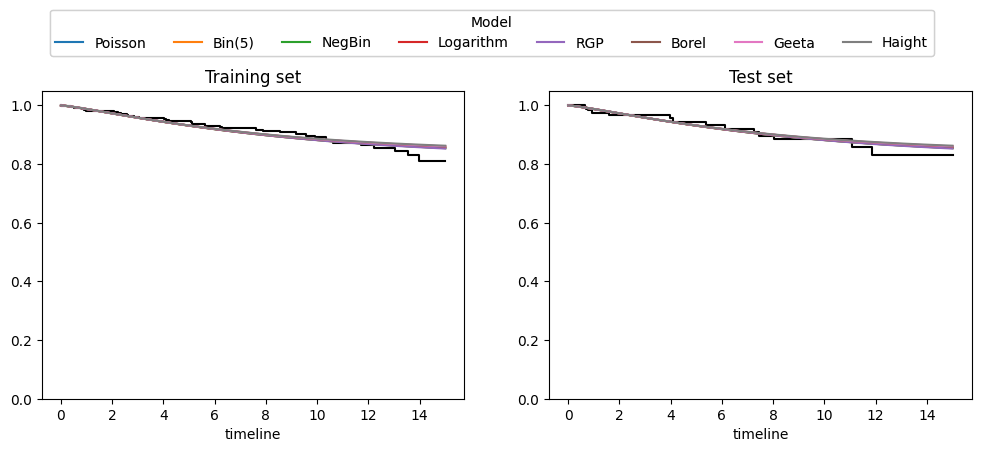

In [21]:
simple_model_results = [poisson_simple_results, bin5_simple_results, negbin_simple_results, log_simple_results,
                        rgp_simple_results, borel_simple_results, geeta_simple_results, haight_simple_results]
model_names = ["Poisson", "Bin(5)", "NegBin", "Logarithm",
               "RGP", "Borel", "Geeta", "Haight"]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))

group_handles = []

for i, result in enumerate(simple_model_results):
    plot_km = False
    if(i == 0):
        plot_km = True
    ts_grid = result["ts_grid"]
    p_train = result["p_train"]
    p_test = result["p_test"]
    S_ts_train = result["S_ts_train"]
    S_ts_test = result["S_ts_test"]
    utils.average_kaplan_meier_train_test(ts_grid,
                                          S_ts_train, S_ts_test,
                                          y_train, delta_train, y_test, delta_test, show_individual = False, ax1 = ax[0], ax2 = ax[1],
                                          color = colors[i], plot_km = plot_km)
    group_handles.append( Line2D([0], [0], color = colors[i], linestyle = '-', label = model_names[i]) )

legend1 = fig.legend(
    handles = group_handles, 
    loc = 'upper center', 
    bbox_to_anchor = (0.5, 1.1),
    title = "Model",
    ncol = len(simple_model_results)
)

fig.add_artist(legend1)

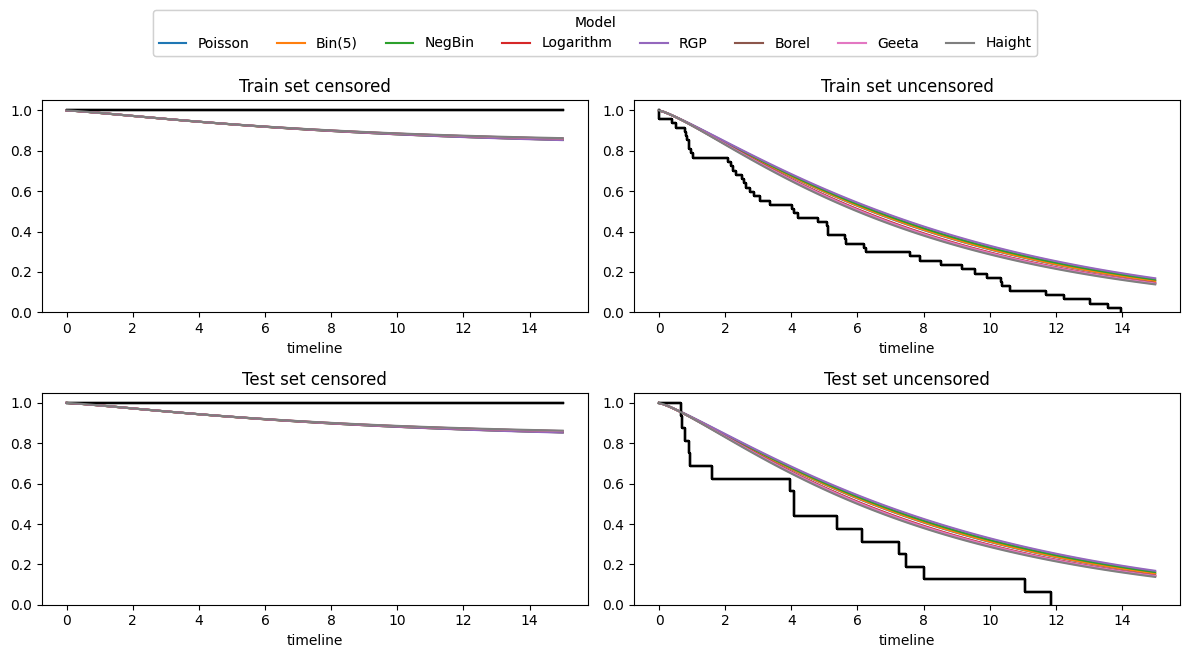

In [22]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (12,6))

group_handles = []

for i, result in enumerate(simple_model_results):
    plot_km = False
    if(i == 0):
        plot_km = True
    plot_censored_susceptible( result, color = colors[i], ax1 = ax[0,0], ax2 = ax[0,1], ax3 = ax[1,0], ax4 = ax[1,1], plot_km = plot_km )
    group_handles.append( Line2D([0], [0], color = colors[i], linestyle = '-', label = model_names[i]) )

# Add the first legend (Groups) - Anchored to the top left
legend1 = fig.legend(
    handles = group_handles, 
    loc = 'upper center', 
    bbox_to_anchor = (0.5, 1.1), # Centered horizontally and pushed just above the figure
    title = "Model",
    ncol = len(simple_model_results) # Dynamically sets columns to match the number of iterations
)

fig.add_artist(legend1)
fig.tight_layout()

### Global base parameter results

In [23]:
print("Fitting Bin(5) Model:")
bin5_medium_model, bin5_medium_results = fit_model("bin", "medium", y_train, delta_train, x_train, y_test, delta_test, x_test, fixed_q = 5.0)
print("Fitting NegBin Model:")
negbin_medium_model, negbin_medium_results = fit_model("negbin", "medium", y_train, delta_train, x_train, y_test, delta_test, x_test)
print("Fitting Logarithm Model:")
log_medium_model, log_medium_results = fit_model("log", "medium", y_train, delta_train, x_train, y_test, delta_test, x_test)
print("Fitting RGP Model:")
rgp_medium_model, rgp_medium_results = fit_model("rgp", "medium", y_train, delta_train, x_train, y_test, delta_test, x_test)
print("Fitting Borel Model:")
borel_medium_model, borel_medium_results = fit_model("borel", "medium", y_train, delta_train, x_train, y_test, delta_test, x_test)
print("Fitting Geeta Model:")
geeta_medium_model, geeta_medium_results = fit_model("geeta", "medium", y_train, delta_train, x_train, y_test, delta_test, x_test)
print("Fitting Haight Model:")
haight_medium_model, haight_medium_results = fit_model("haight", "medium", y_train, delta_train, x_train, y_test, delta_test, x_test)

Fitting Bin(5) Model:
GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 379 / 10000 ]  | Avg. Train NLL:  0.479482472 | Avg. Validation NLL:  0.540491045 | Best Avg. Validation NLL:  0.539609551 | Speed:  0.0718349293  epoch/s    | Elapsed Time:  27.2254372  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 1056 / 10000 ]  | Avg. Train NLL:  0.437956512 | Best Avg. Train NLL:  0.437956512 | Avg. Validation NLL:  0.519307494 | Speed:  0.0841317773  epoch/s    | Elapsed Time:  88.8431549  s   
Convergence criterion reached. Stopping.
Restoring best weights...

Done.
Extracting covariance structure.
Done.
Optimization finished in 119.797 seconds.
Fitting NegBin Model:
GPU detected. Activating GPU determinism. To reverse this, the Py

In [24]:
poisson_medium_model.save_model("OASIS Results/WeibullBase/poisson_medium")
bin5_medium_model.save_model("OASIS Results/WeibullBase/bin5_medium")
negbin_medium_model.save_model("OASIS Results/WeibullBase/negbin_medium")
log_medium_model.save_model("OASIS Results/WeibullBase/log_medium")
rgp_medium_model.save_model("OASIS Results/WeibullBase/rgp_medium")
borel_medium_model.save_model("OASIS Results/WeibullBase/borel_medium")
geeta_medium_model.save_model("OASIS Results/WeibullBase/geeta_medium")
haight_medium_model.save_model("OASIS Results/WeibullBase/haight_medium")

Model successfully saved to OASIS Results/WeibullBase/poisson_medium.weights.h5 and OASIS Results/WeibullBase/poisson_medium_meta.pkl
Model successfully saved to OASIS Results/WeibullBase/bin5_medium.weights.h5 and OASIS Results/WeibullBase/bin5_medium_meta.pkl
Model successfully saved to OASIS Results/WeibullBase/negbin_medium.weights.h5 and OASIS Results/WeibullBase/negbin_medium_meta.pkl
Model successfully saved to OASIS Results/WeibullBase/log_medium.weights.h5 and OASIS Results/WeibullBase/log_medium_meta.pkl
Model successfully saved to OASIS Results/WeibullBase/rgp_medium.weights.h5 and OASIS Results/WeibullBase/rgp_medium_meta.pkl
Model successfully saved to OASIS Results/WeibullBase/borel_medium.weights.h5 and OASIS Results/WeibullBase/borel_medium_meta.pkl
Model successfully saved to OASIS Results/WeibullBase/geeta_medium.weights.h5 and OASIS Results/WeibullBase/geeta_medium_meta.pkl
Model successfully saved to OASIS Results/WeibullBase/haight_medium.weights.h5 and OASIS Resul

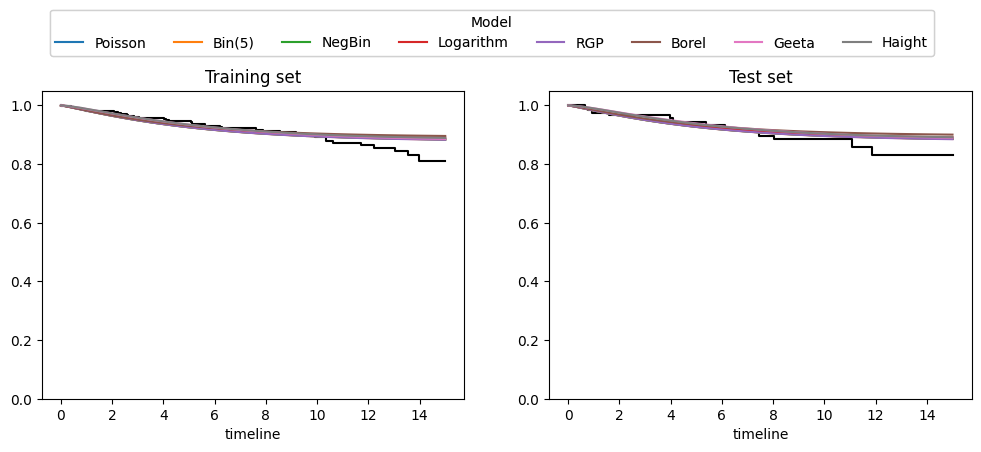

In [25]:
medium_model_results = [poisson_medium_results, bin5_medium_results, negbin_medium_results, log_medium_results,
                        rgp_medium_results, borel_medium_results, geeta_medium_results, haight_medium_results]
model_names = ["Poisson", "Bin(5)", "NegBin", "Logarithm",
               "RGP", "Borel", "Geeta", "Haight"]

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))

group_handles = []

for i, result in enumerate(medium_model_results):
    plot_km = False
    if(i == 0):
        plot_km = True
    ts_grid = result["ts_grid"]
    p_train = result["p_train"]
    p_test = result["p_test"]
    S_ts_train = result["S_ts_train"]
    S_ts_test = result["S_ts_test"]
    utils.average_kaplan_meier_train_test(ts_grid,
                                          S_ts_train, S_ts_test,
                                          y_train, delta_train, y_test, delta_test, show_individual = False, ax1 = ax[0], ax2 = ax[1],
                                          color = colors[i], plot_km = plot_km)
    group_handles.append( Line2D([0], [0], color = colors[i], linestyle = '-', label = model_names[i]) )

# Add the first legend (Groups) - Anchored to the top left
legend1 = fig.legend(
    handles = group_handles, 
    loc = 'upper center', 
    bbox_to_anchor = (0.5, 1.1), # Centered horizontally and pushed just above the figure
    title = "Model",
    ncol = len(medium_model_results) # Dynamically sets columns to match the number of iterations
)

fig.add_artist(legend1)
plt.show()

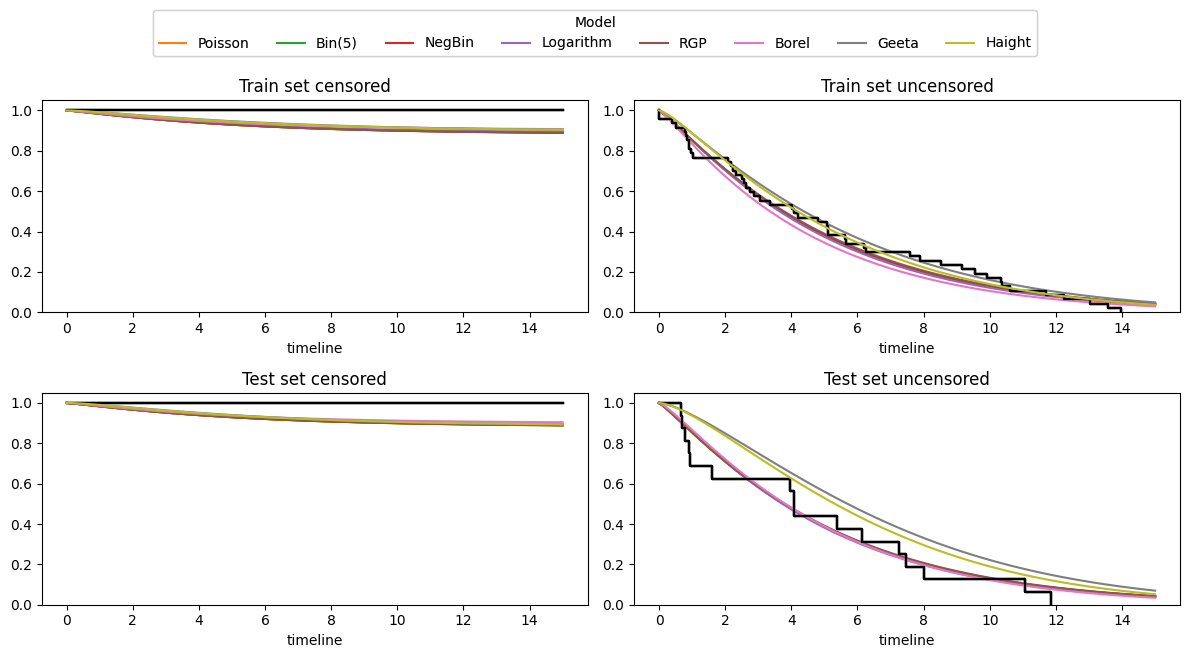

In [26]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (12,6))

group_handles = []

for i, result in enumerate(medium_model_results):
    plot_km = False
    if(i == 0):
        plot_km = True
    plot_censored_susceptible( result, color = colors[i+1], ax1 = ax[0,0], ax2 = ax[0,1], ax3 = ax[1,0], ax4 = ax[1,1], plot_km = plot_km, show_individual = False )
    group_handles.append( Line2D([0], [0], color = colors[i+1], linestyle = '-', label = model_names[i]) )

legend1 = fig.legend(
    handles = group_handles, 
    loc = 'upper center', 
    bbox_to_anchor = (0.5, 1.1),
    title = "Model",
    ncol = len(medium_model_results)
)

fig.add_artist(legend1) 

# Prevent the top legends from being clipped off the final image
plt.tight_layout()

# Geeta

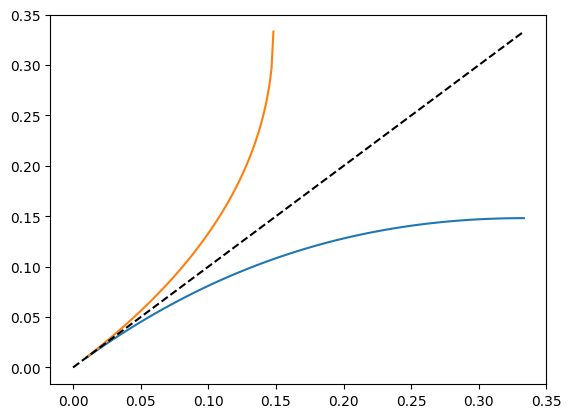

In [27]:
geeta_spec = mpscr.MPSGeeta()

q = 3
theta = tf.cast( np.linspace(0.01, 1/q, 100), tf.float32 )
u = tf.cast( np.linspace(0.01, geeta_spec.phi(1/q, q), 100), tf.float32 )

plt.plot(theta, geeta_spec.phi(theta, q))
plt.plot(u, geeta_spec.phi_inv(u, q))
plt.plot([0, 1/q], [0, 1/q], color = "black", linestyle = "dashed")

plt.show()